# Cross-Entropy Method

In [54]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

### Cost Function

\begin{align}
f(x_1, x_2) = (x_1+x_2-3)^2+(2x_1-6x_2-4)^2
\end{align}

In [55]:
def compute_cost(x):
    x_1 = x[:, 0]
    x_2 = x[:, 1]

    cost = (x_1 + x_2 - 3)**2 + (2*x_1 - 6*x_2 - 4)**2
    return cost

x_1_grid = np.linspace(-3, 3)
x_2_grid = np.linspace(-3, 3)
X_1, X_2 = np.meshgrid(x_1_grid, x_2_grid)

f = (X_1 + X_2 - 3)**2 + (2*X_1 - 6*X_2 - 4)**2

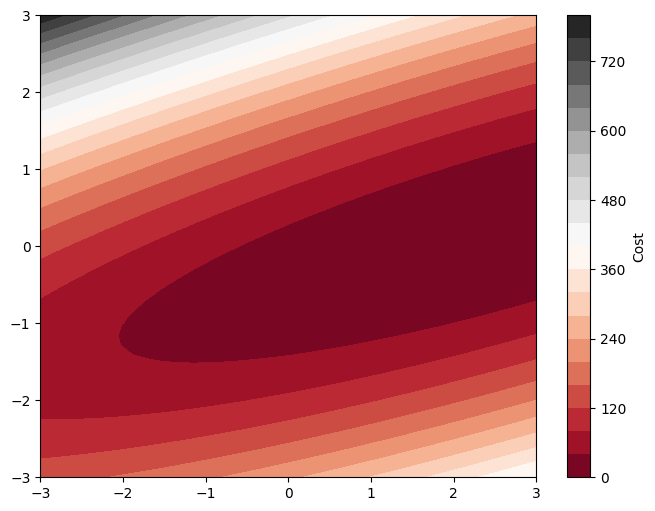

In [56]:
plt.figure(figsize=(8, 6))
plt.contourf(X_1, X_2, f, 20, cmap='RdGy')
plt.colorbar(label='Cost')
plt.show()

### 1. Pure Random Sampling

In [57]:
num_random_samples = 1000

# Sample uniformly from [-3, 3] for both x_1 and x_2
random_samples = (torch.rand((num_random_samples, 2)) * 6) - 3

# Evaluate all samples at once
random_costs = compute_cost(random_samples)

best_idx_random = torch.argmin(random_costs)
best_x_random = random_samples[best_idx_random]
best_cost_random = random_costs[best_idx_random]

print(f"Best cost found= {best_cost_random.item():.4f}")
print(f"Best x found= {best_x_random.numpy()}\n")

Best cost found= 0.0737
Best x found= [2.5463343  0.19676495]



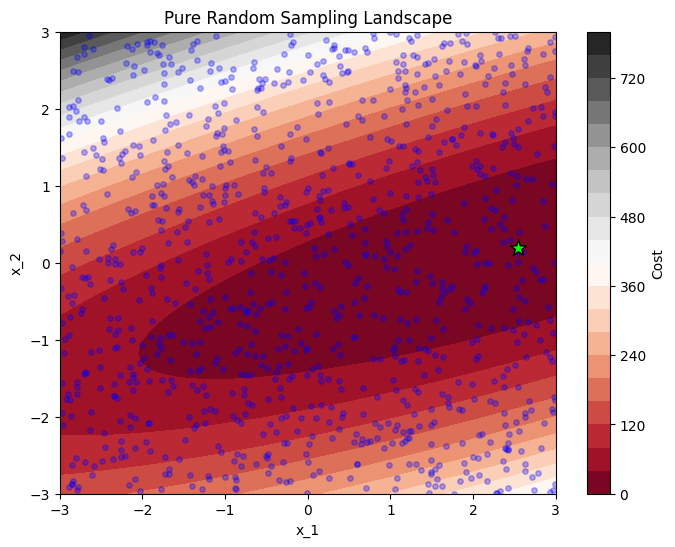

In [58]:
plt.figure(figsize=(8, 6))
plt.contourf(X_1, X_2, f, 20, cmap='RdGy')
plt.colorbar(label='Cost')

plt.scatter(random_samples[:, 0].numpy(), random_samples[:, 1].numpy(),
            c='blue', alpha=0.3, s=15, label='Random Samples')

plt.scatter(best_x_random[0].numpy(), best_x_random[1].numpy(),
            c='lime', edgecolors='black', s=150, marker='*', label='Best Found')

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.title("Pure Random Sampling Landscape")
plt.xlabel("x_1")
plt.ylabel("x_2")
# plt.legend()
plt.show()

### 2. CEM: Importance Sampling

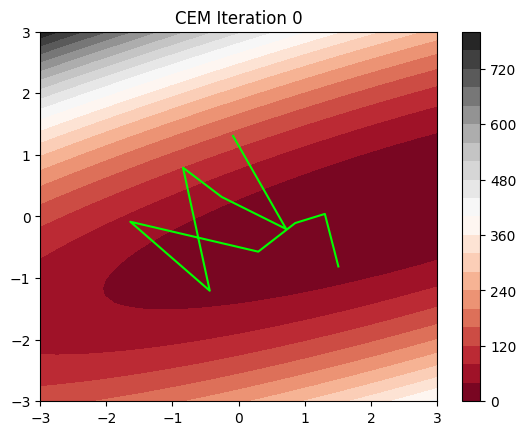

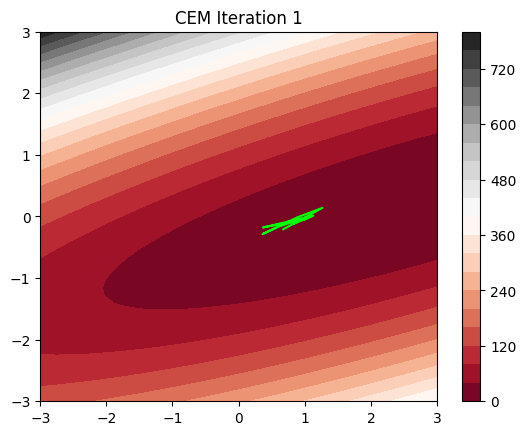

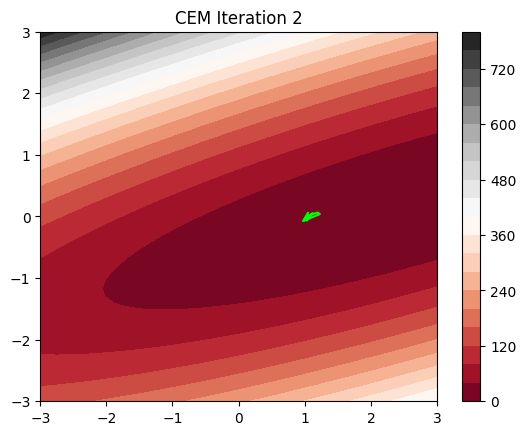

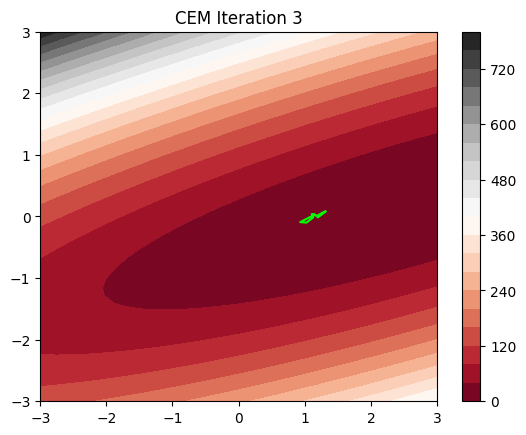

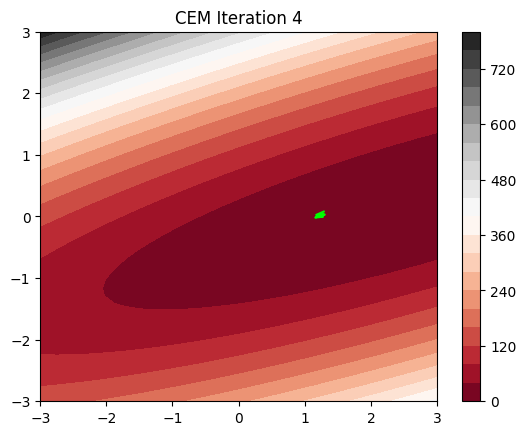

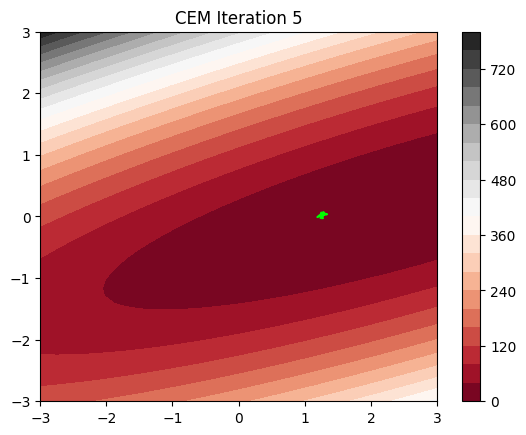

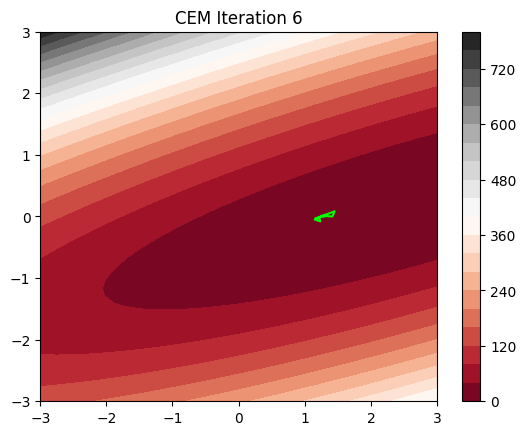

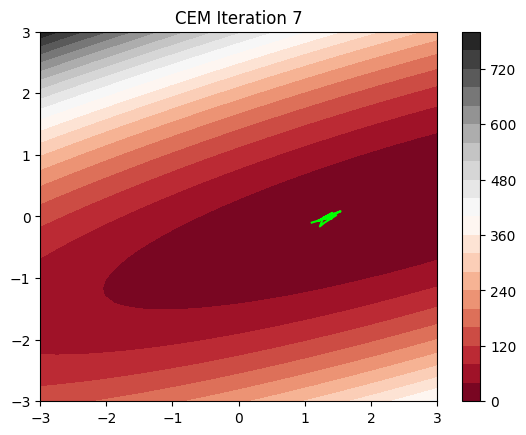

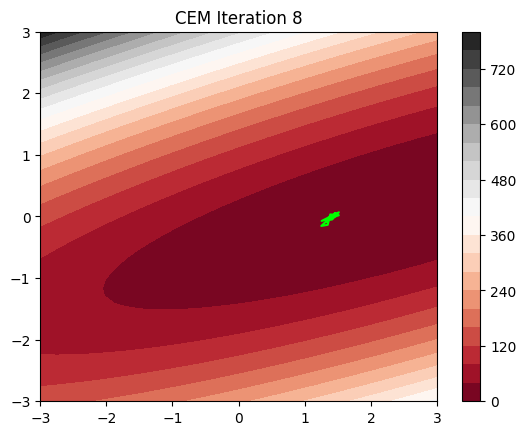

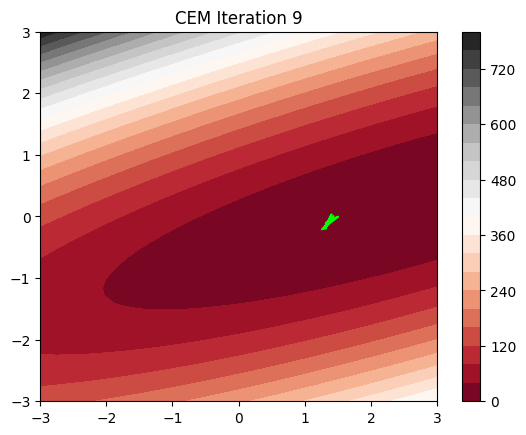

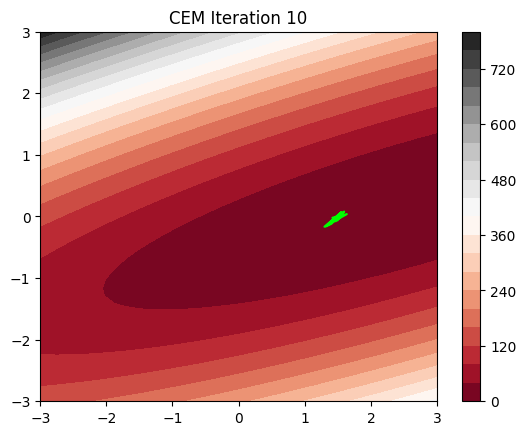

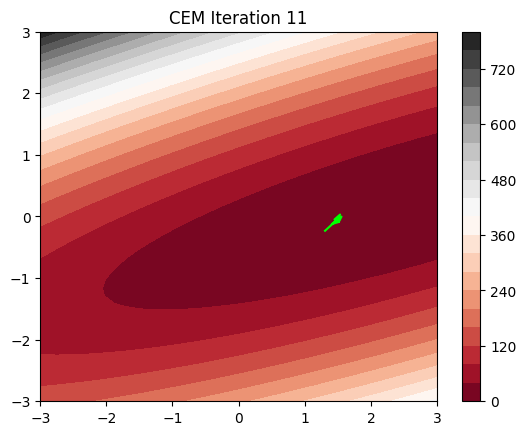

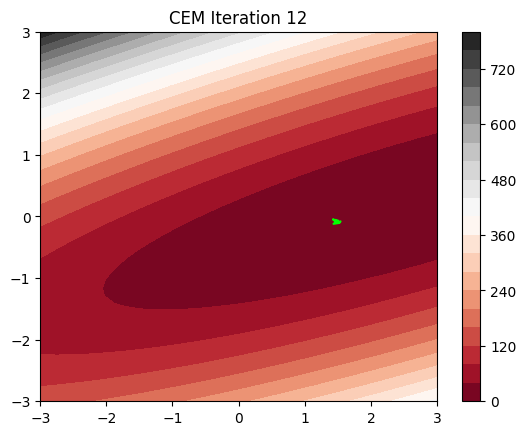

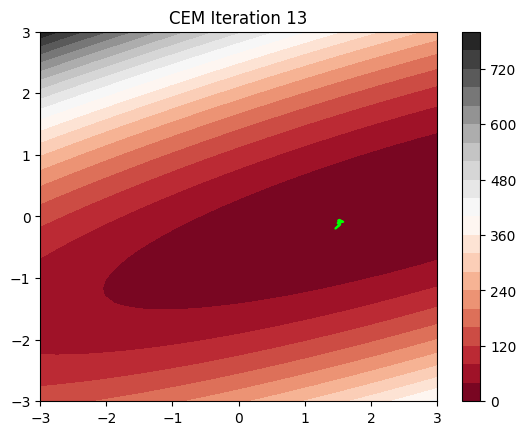

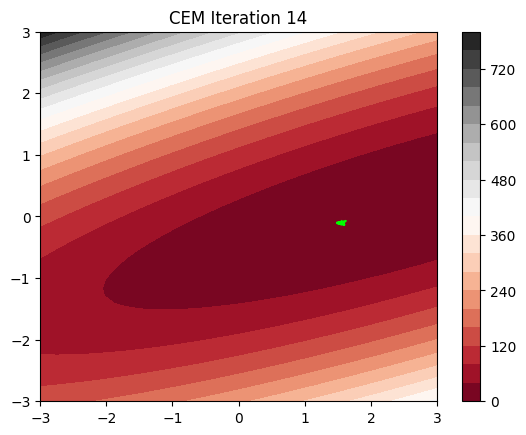

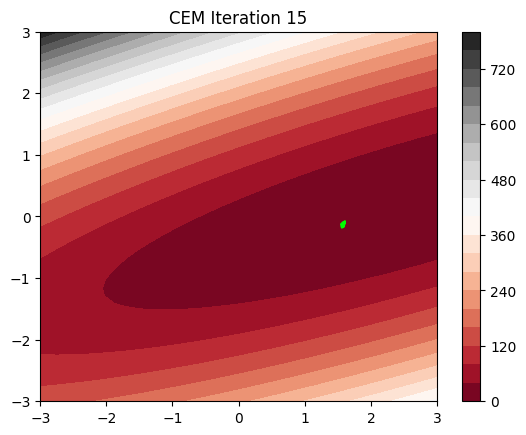

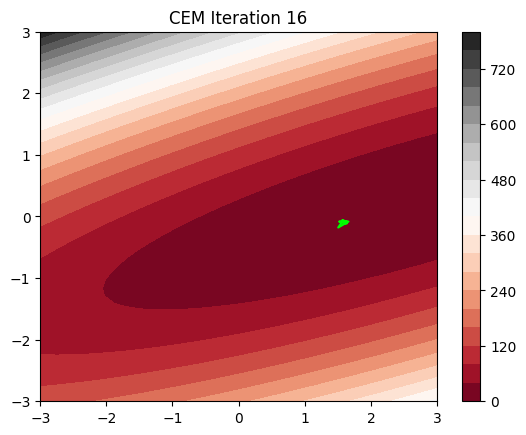

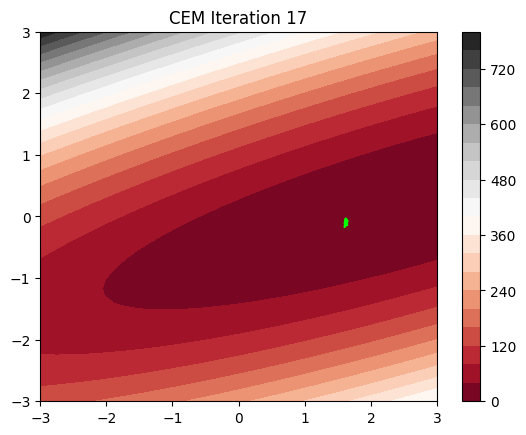

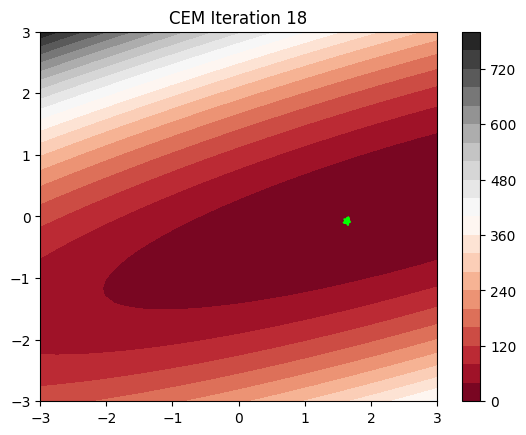

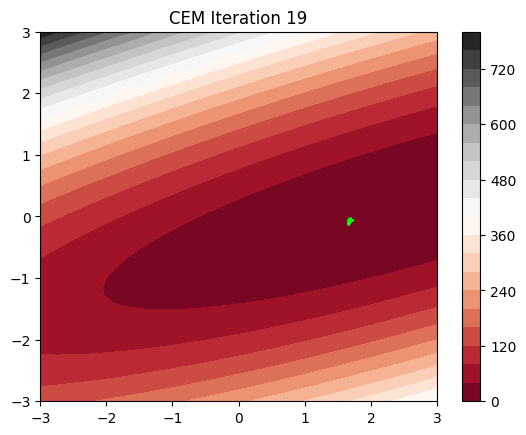

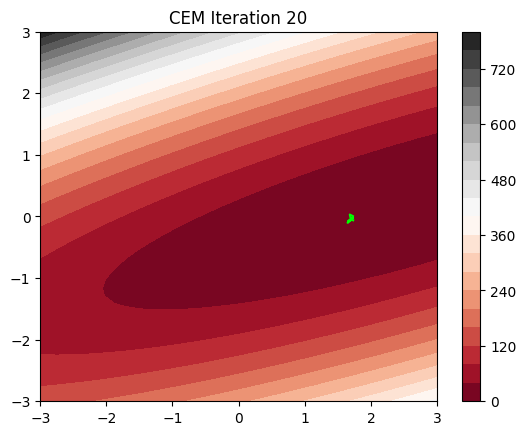

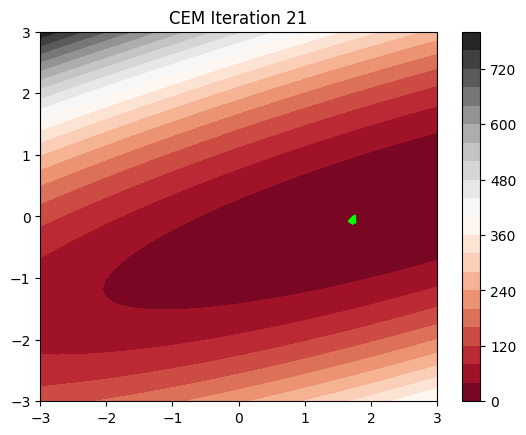

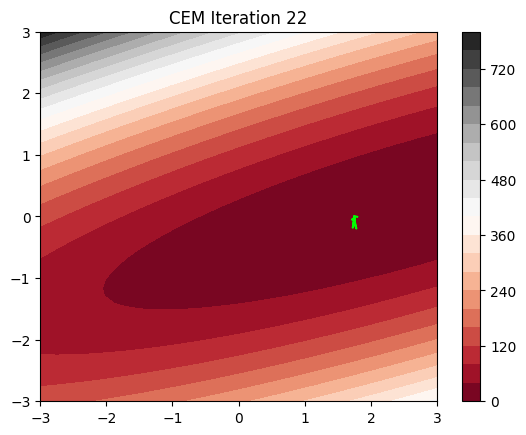

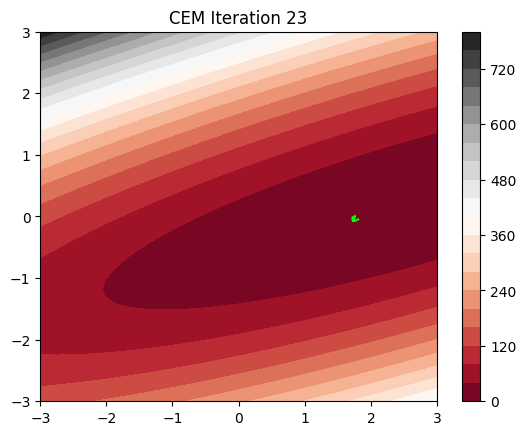

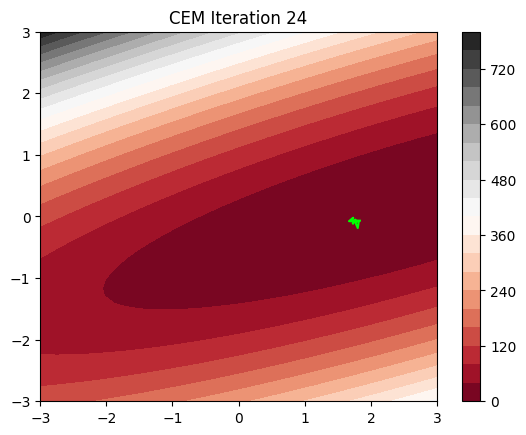

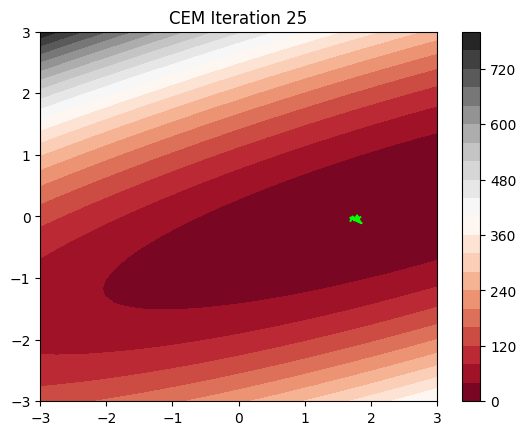

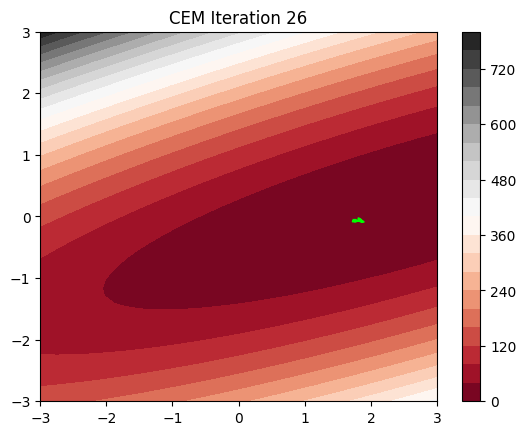

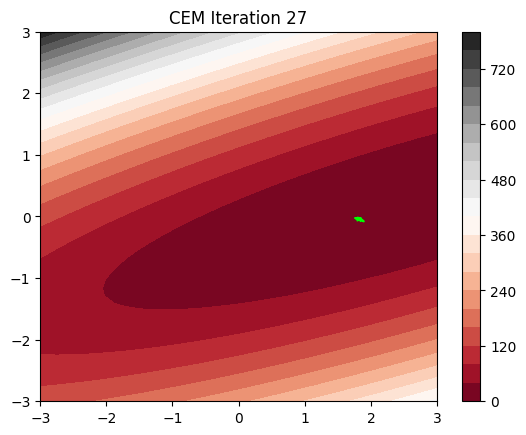

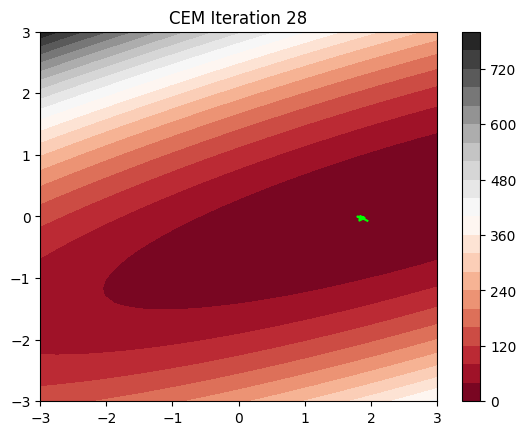

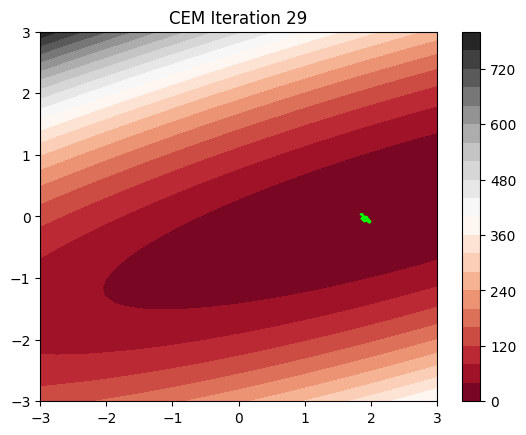

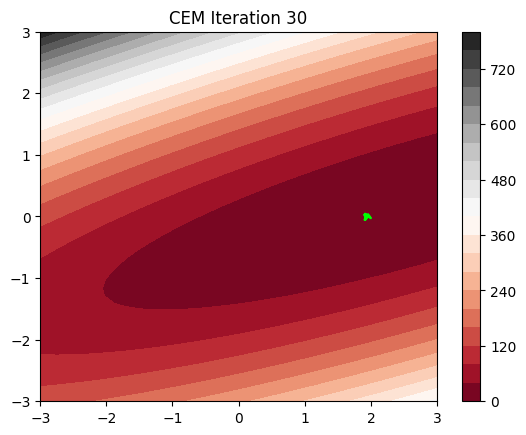

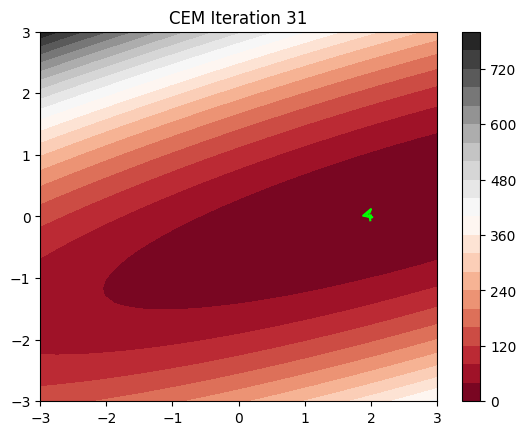

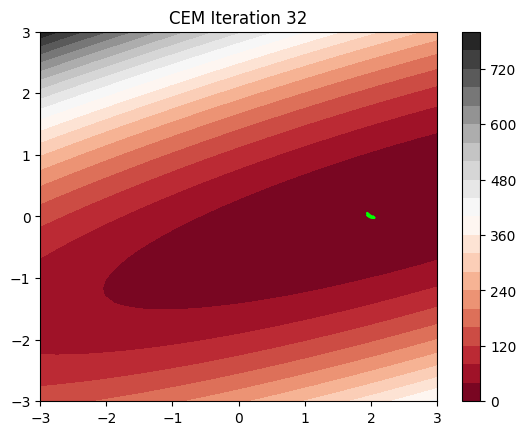

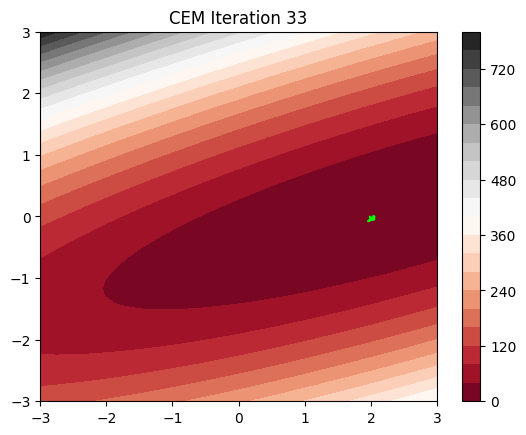

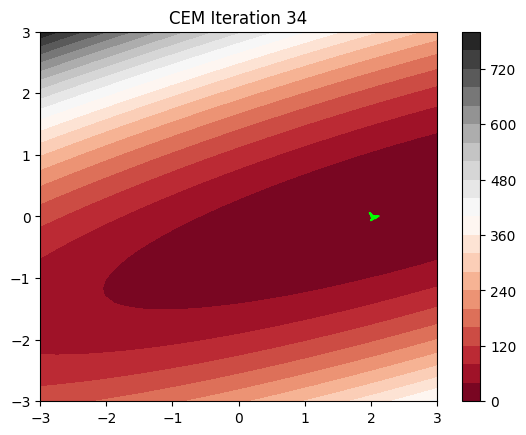

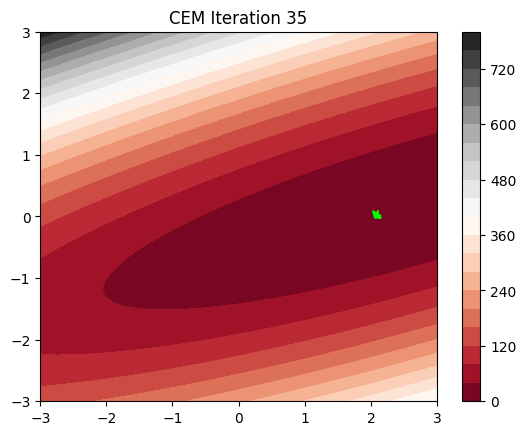

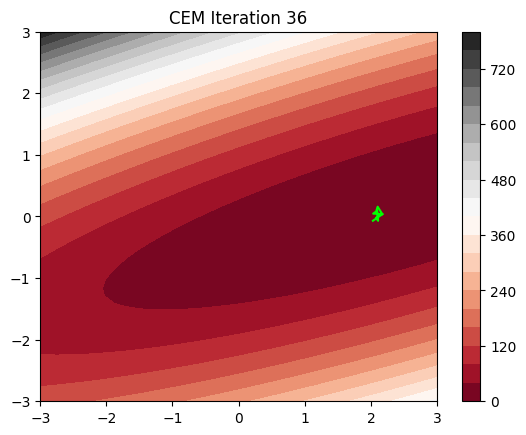

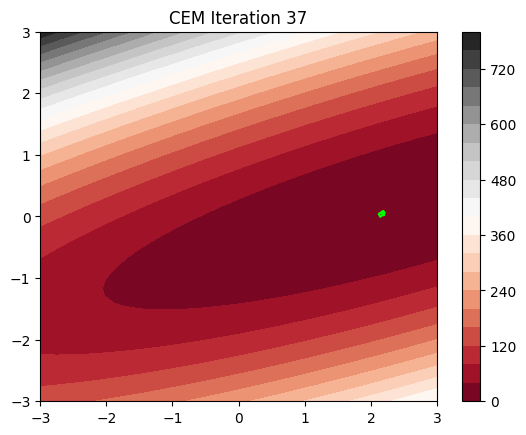

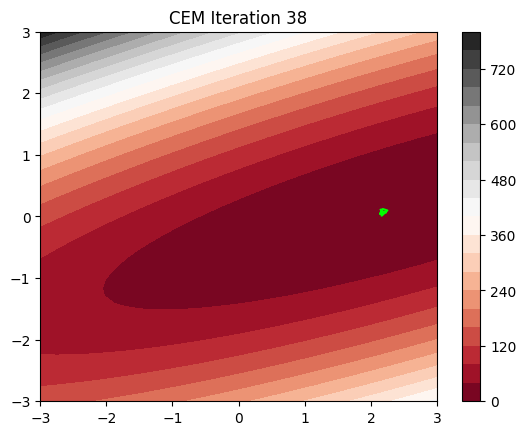

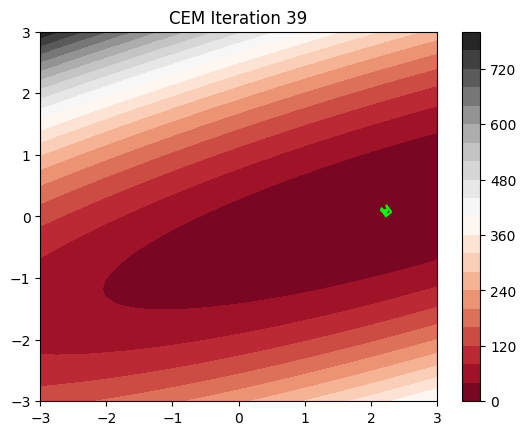

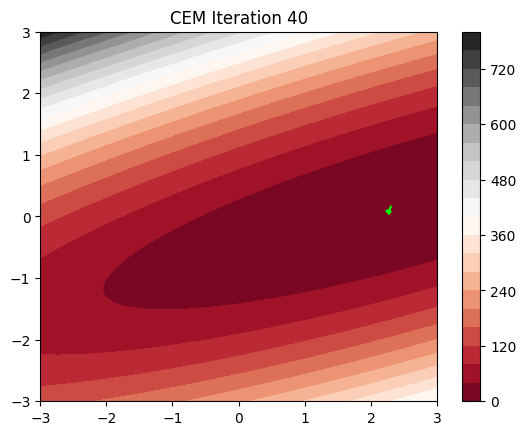

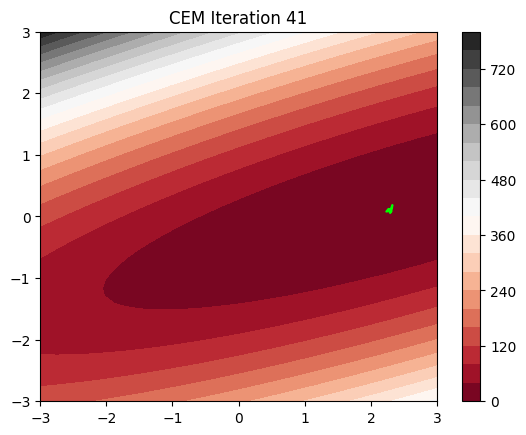

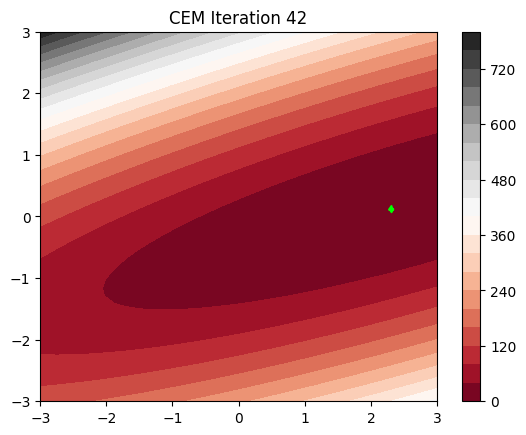

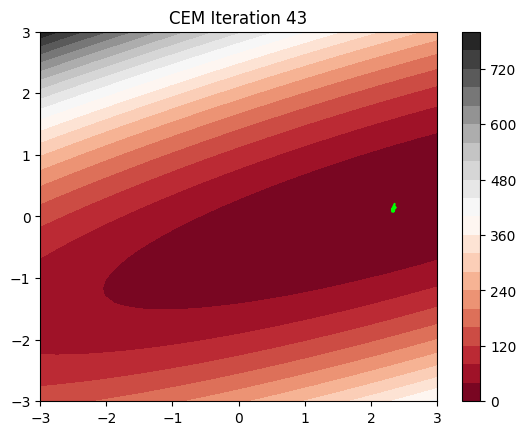

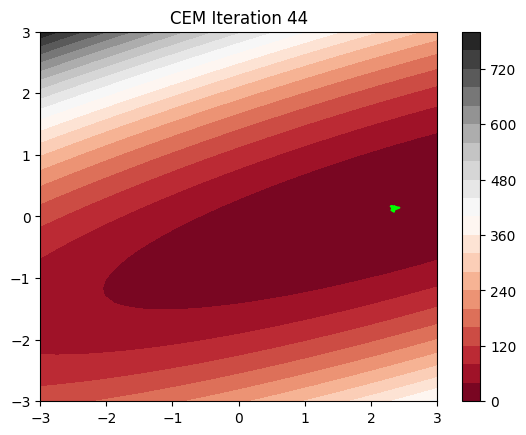

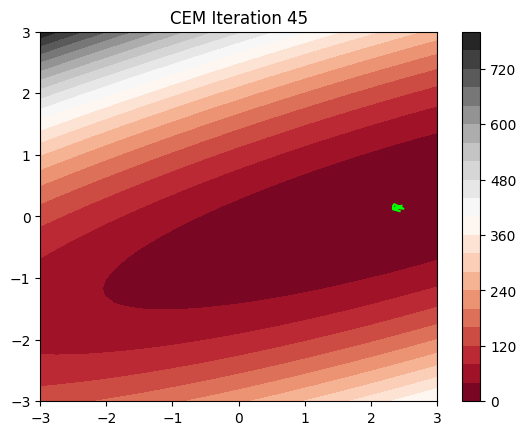

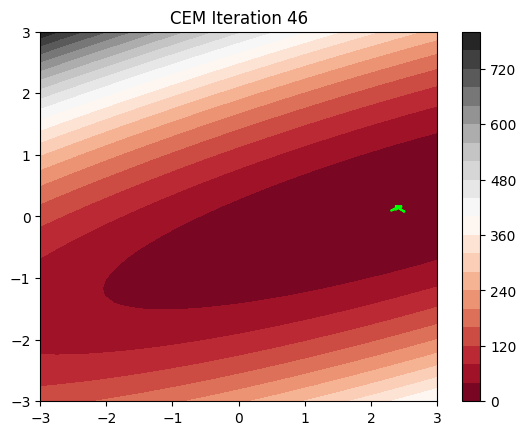

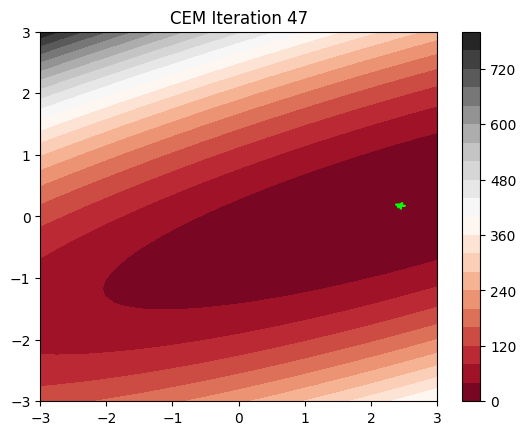

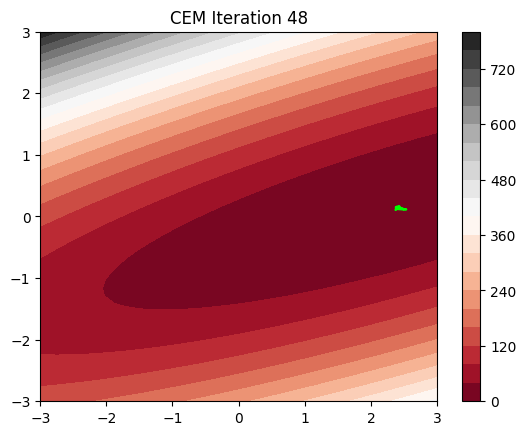

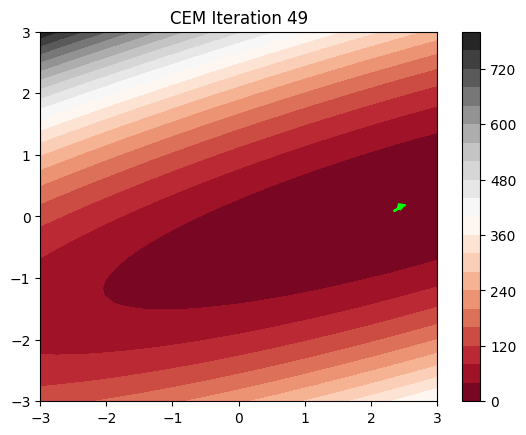

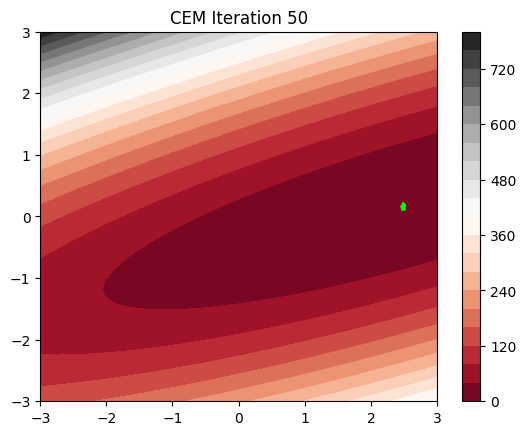

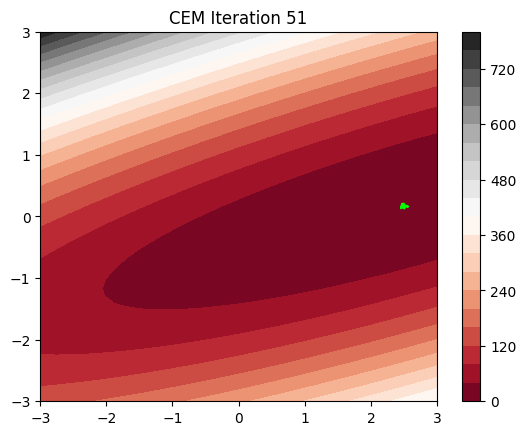

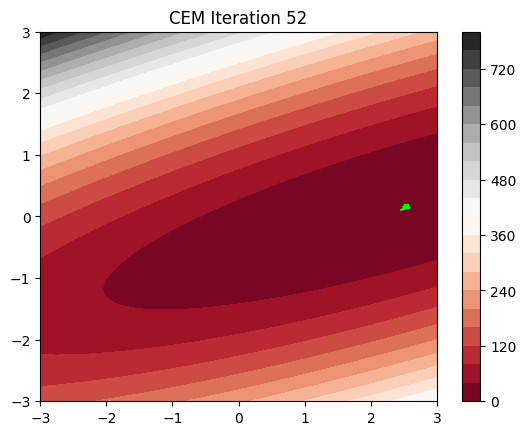

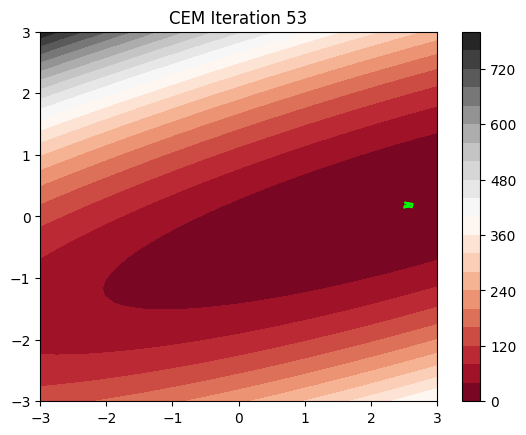

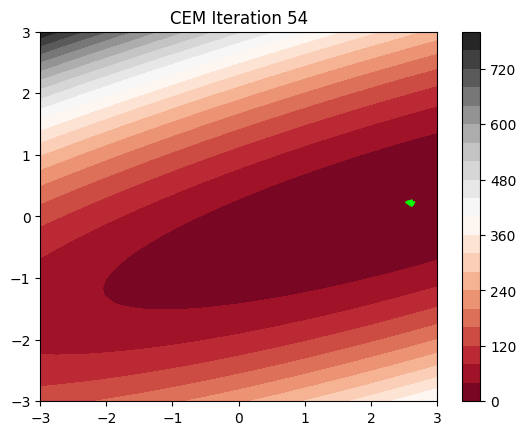

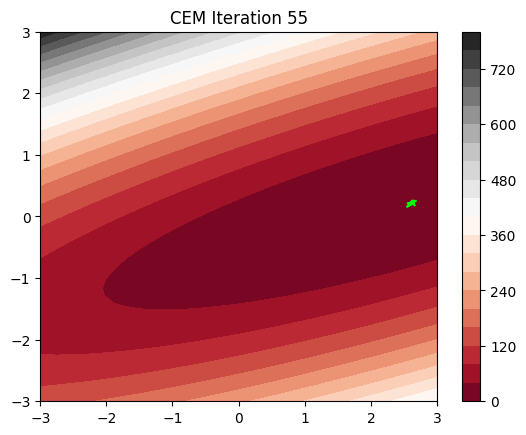

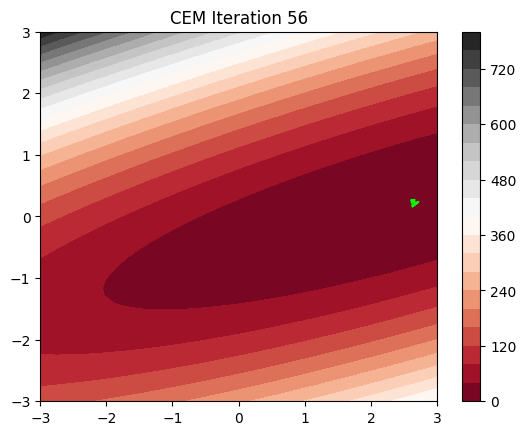

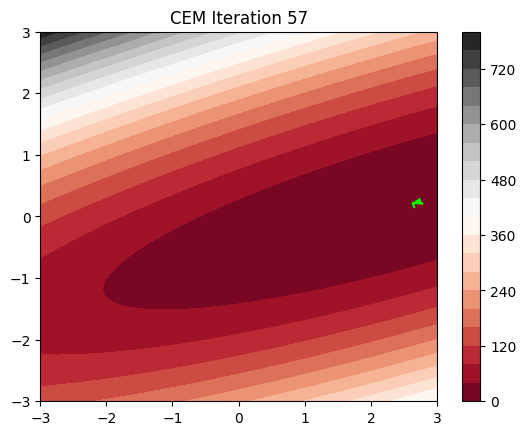

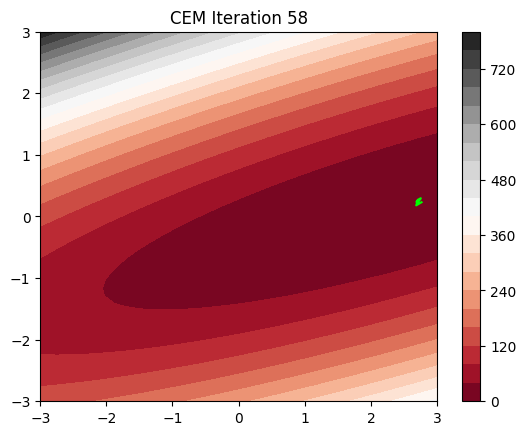

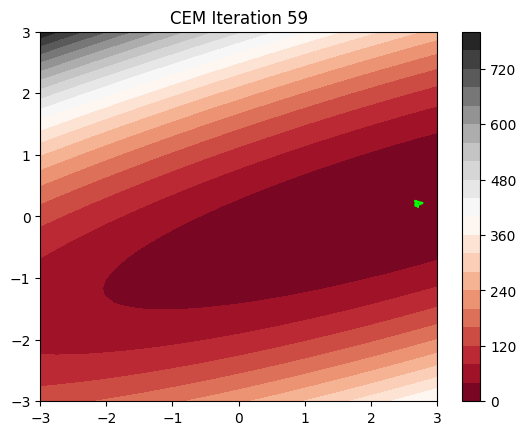

In [59]:
init_mean = torch.tensor([0.0, 0.0])
init_cov = torch.eye(2)
num_samples = 10
maxiter = 60
alpha = 0.9

cost_track = []

for i in range(maxiter):
    mean_prev = init_mean.clone()

    # Step 1: Sampling
    dist = torch.distributions.MultivariateNormal(init_mean, init_cov)
    x = dist.sample((num_samples,))

    # Step 2: Evaluating f(x)
    cost_samples = compute_cost(x)

    # Step 3: Sorting to find elites
    idx = torch.argsort(cost_samples)

    plt.plot(x[:, 0].numpy(), x[:, 1].numpy(), color='lime')
    plt.contourf(X_1, X_2, f, 20, cmap='RdGy')
    plt.colorbar()
    plt.xlim(-3, 3); plt.ylim(-3, 3)
    plt.title(f"CEM Iteration {i}")
    plt.show()

    # Taking top k% (Elites)
    elite_num = int(num_samples * 0.3)
    x_elite = x[idx[:elite_num]]

    # Step 4: Updating parameters (The Importance Sampling shift)
    init_mean_temp = torch.mean(x_elite, dim=0)
    init_mean = alpha * init_mean_temp + (1 - alpha) * mean_prev

    # Update Covariance
    # We add a small identity matrix to prevent the covariance from collapsing to 0
    init_cov = torch.cov(x_elite.T) + 0.001 * torch.eye(2)

    cost_track.append(torch.min(cost_samples).item())

Best cost= 0.0117
x_best= [2.6751342  0.22039394]


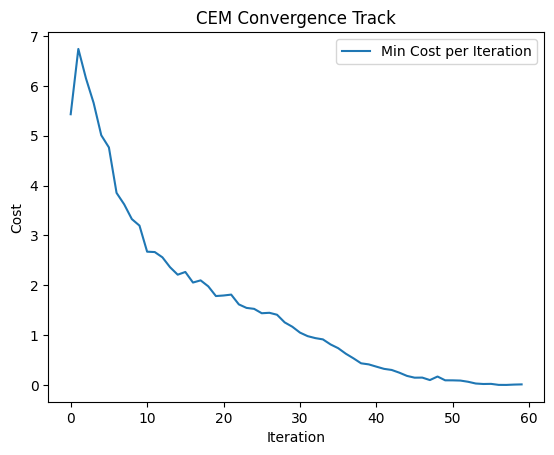

In [60]:
idx_min = torch.argmin(cost_samples)

print(f"Best cost= {cost_samples[idx_min].item():.4f}")
print(f"x_best= {x[idx_min].numpy()}")

plt.figure()
plt.plot(cost_track, label="Min Cost per Iteration")
plt.title("CEM Convergence Track")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.show()

# CEM: Goal Reaching for Unicycle Model

In [61]:
dt = 0.1
horizon = 40
init_state = torch.tensor([0.0, 0.0, 0.0]) # [x, y, theta]
goal_state = torch.tensor([5.0, 5.0])      # [x_goal, y_goal]

# CEM parameters
num_samples = 500   # Number of trajectories to sample per iteration
maxiter = 30    # Number of CEM iterations
elite_frac = 0.1    # Top 10% are elites
alpha = 0.8 # Smoothing factor for updates (momentum)

In [62]:
def rollout_unicycle(controls, start_state):
    """
    controls: (num_samples, horizon, 2)  -> [v, omega]
    start_state:-> [x, y, theta]

    Returns:
    new_states: (num_samples, horizon+1, 3)
    """
    N = controls.shape[0]

    # Initialize state tensor to hold the full trajectory for all samples
    states = torch.zeros((N, horizon + 1, 3))
    states[:, 0, :] = start_state

    for t in range(horizon):
        v = controls[:, t, 0]
        omega = controls[:, t, 1]

        theta_current = states[:, t, 2]

        # Euler integration
        states[:, t+1, 0] = states[:, t, 0] + v * torch.cos(theta_current) * dt
        states[:, t+1, 1] = states[:, t, 1] + v * torch.sin(theta_current) * dt
        states[:, t+1, 2] = states[:, t, 2] + omega * dt

    return states

def compute_cost(states, goal):
    """
    states: (num_samples, horizon+1, 3)
    """
    final_positions = states[:, -1, :2] # endpoint

    return torch.norm(final_positions - goal, dim=1)

### CEM Loop

Iteration  0 | Best Dist to Goal: 4.3884
Iteration  5 | Best Dist to Goal: 0.1345
Iteration 10 | Best Dist to Goal: 0.1151
Iteration 15 | Best Dist to Goal: 0.1088
Iteration 20 | Best Dist to Goal: 0.0761
Iteration 25 | Best Dist to Goal: 0.0260
Iteration 29 | Best Dist to Goal: 0.0297


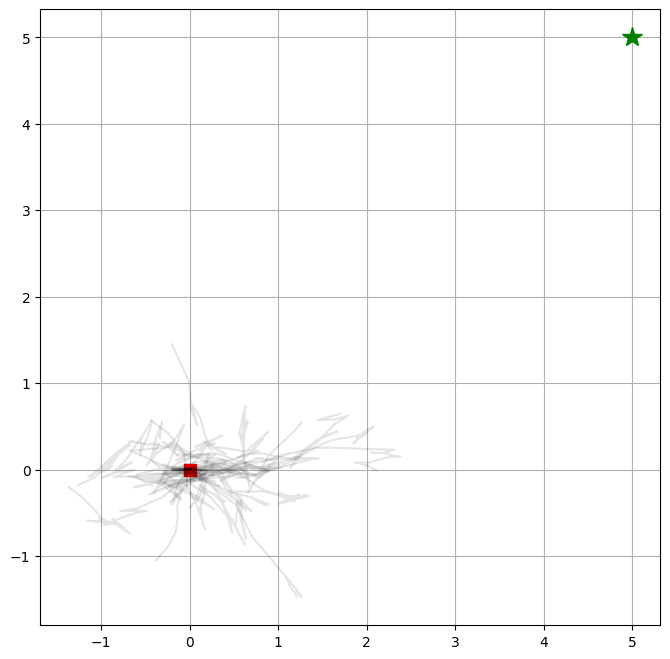

In [63]:
# Initialize probability distribution parameters for controls
# We maintain an independent Normal distribution for each timestep and action
mean_ctrl = torch.zeros(horizon, 2)
# Start with a wide standard deviation to encourage exploration
std_ctrl = torch.ones(horizon, 2) * 2.0

cost_history = []
elite_num = int(num_samples * elite_frac)

plt.figure(figsize=(8, 8))
plt.plot(goal_state[0], goal_state[1], 'g*', markersize=15, label="Goal")
plt.plot(init_state[0], init_state[1], 'rs', markersize=8, label="Start")

for i in range(maxiter):
    # Step 1: Sample control sequences
    dist = torch.distributions.Normal(mean_ctrl, std_ctrl)
    controls = dist.sample((num_samples,)) # Shape: (500, 40, 2)

    # Optional, but imp: Clamp controls to physical limits
    controls[:, :, 0] = torch.clamp(controls[:, :, 0], min=-2.0, max=5.0) # v limits
    controls[:, :, 1] = torch.clamp(controls[:, :, 1], min=-3.0, max=3.0) # omega limits

    # Step 2: Rollout dynamics & Evaluate cost
    states = rollout_unicycle(controls, init_state)
    costs = compute_cost(states, goal_state)

    # Step 3: Sort and extract elites
    idx = torch.argsort(costs)
    elite_controls = controls[idx[:elite_num]]

    if i == 0:
        for j in range(20): # Plot 20 random trajectories
            traj = states[j].numpy()
            plt.plot(traj[:, 0], traj[:, 1], 'k-', alpha=0.1)
            plt.grid(True)

    # Step 4: Update distributions
    new_mean = torch.mean(elite_controls, dim=0)
    # Add small epsilon to std to prevent covariance collapse (premature convergence)
    new_std = torch.std(elite_controls, dim=0) + 0.05

    mean_ctrl = alpha * new_mean + (1 - alpha) * mean_ctrl
    std_ctrl  = alpha * new_std  + (1 - alpha) * std_ctrl

    best_cost = costs[idx[0]].item()
    cost_history.append(best_cost)

    if i % 5 == 0 or i == maxiter - 1:
        print(f"Iteration {i:2d} | Best Dist to Goal: {best_cost:.4f}")

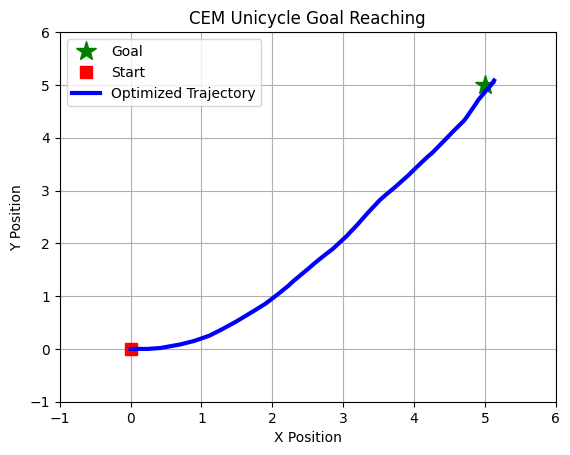

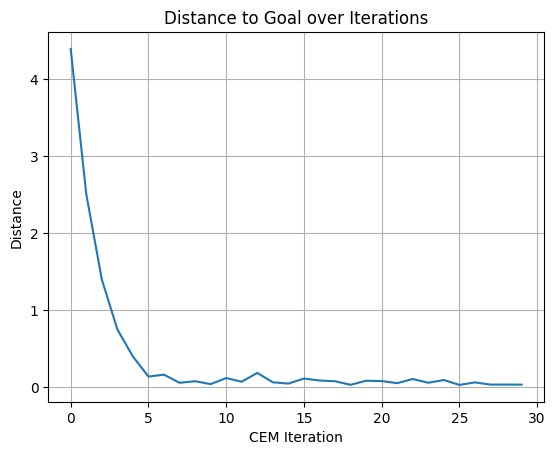

In [64]:
# Rollout the final, optimized mean control sequence
optimal_states = rollout_unicycle(mean_ctrl.unsqueeze(0), init_state)[0].numpy()

plt.plot(goal_state[0], goal_state[1], 'g*', markersize=15, label="Goal")
plt.plot(init_state[0], init_state[1], 'rs', markersize=8, label="Start")

plt.plot(optimal_states[:, 0], optimal_states[:, 1], 'b-', linewidth=3, label="Optimized Trajectory")
plt.xlim(-1, 6); plt.ylim(-1, 6)
plt.title("CEM Unicycle Goal Reaching")
plt.xlabel("X Position"); plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(cost_history)
plt.title("Distance to Goal over Iterations")
plt.xlabel("CEM Iteration"); plt.ylabel("Distance")
plt.grid(True)
plt.show()